# Customer Churn Analysis

## Project Overview

In this project, I worked with a telecom customer churn dataset to understand why customers leave and how to reduce churn.

## Dataset

The dataset has 7043 customers and 21 columns.
The target variable is 'Churn', which shows whether a customer left the company.

There are 5,174 customers who stayed and 1,869 customers who churned, resulting in an overall churn rate of about 26%.

## Initial Thoughts

At this stage, I want to first understand the data using SQL and Python before building a model.
I will focus on simple and explainable factors such as contract type, tenure, and monthly charges.

## Data Loading and Overview

In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
print(df["Churn"].value_counts())
print(df.isnull().sum())


(7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## SQL Analysis

I started with SQL to quickly explore the data and identify initial patterns.

### Churn Distribution
This query shows how many customers stayed vs churned.

### Churn by Contract Type
This analysis helps identify which contract types have higher churn rates.

### Key Finding

From the results, customers on month-to-month contracts have a much higher churn rate (about 43%) compared to one-year (11%) and two-year contracts (around 3%).

This suggests that contract length is strongly related to customer retention.

In [2]:
import sqlite3

conn = sqlite3.connect("churn.db")

df.to_sql("customers", conn, if_exists="replace", index=False)

7043

In [3]:
pd.read_sql("SELECT COUNT(*) FROM customers", conn)

,COUNT(*)
0,7043


In [4]:
pd.read_sql("""
SELECT Churn, COUNT(*) as count
FROM customers
GROUP BY Churn
""", conn)

,Churn,count
0,No,5174
1,Yes,1869


In [5]:
pd.read_sql("""
SELECT 
    Contract,
    COUNT(*) as total,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned
FROM customers
GROUP BY Contract
""", conn)

,Contract,total,churned
0,Month-to-month,3875,1655
1,One year,1473,166
2,Two year,1695,48


In [6]:
pd.read_sql("""
SELECT 
    Contract,
    COUNT(*) as total,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned,
    ROUND(1.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 3) as churn_rate
FROM customers
GROUP BY Contract
""", conn)

,Contract,total,churned,churn_rate
0,Month-to-month,3875,1655,0.427
1,One year,1473,166,0.113
2,Two year,1695,48,0.028


## Exploratory Data Analysis (EDA)

After the SQL analysis, I used Python to further explore the relationships between different variables and churn.

The goal here is to identify patterns that may help explain why customers leave.

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

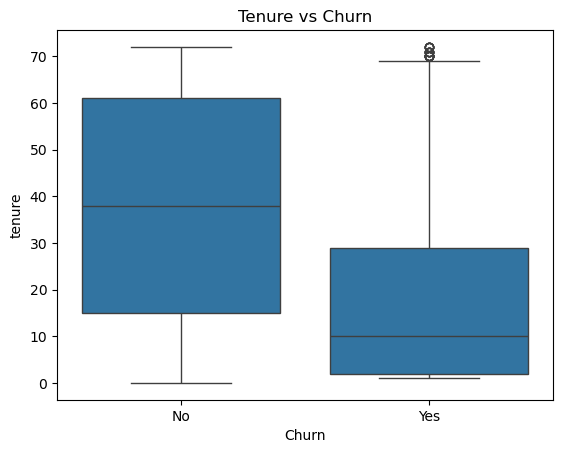

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

### Tenure and Churn

Customers who churn tend to have shorter tenure compared to those who stay.

This suggests that newer customers are more likely to leave.

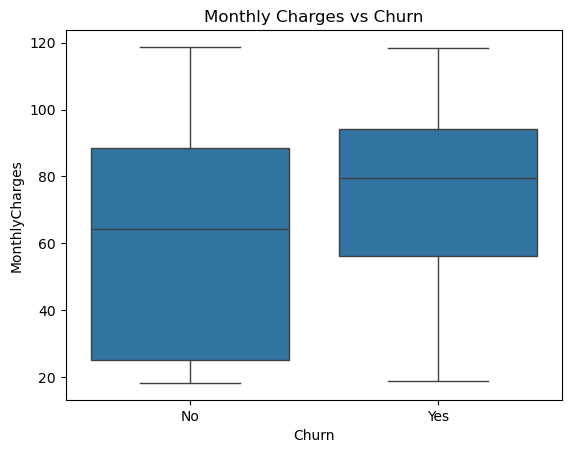

In [10]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

### Monthly Charges and Churn

Customers with higher monthly charges tend to have a higher churn rate.

This may indicate that pricing plays a role in customer retention.

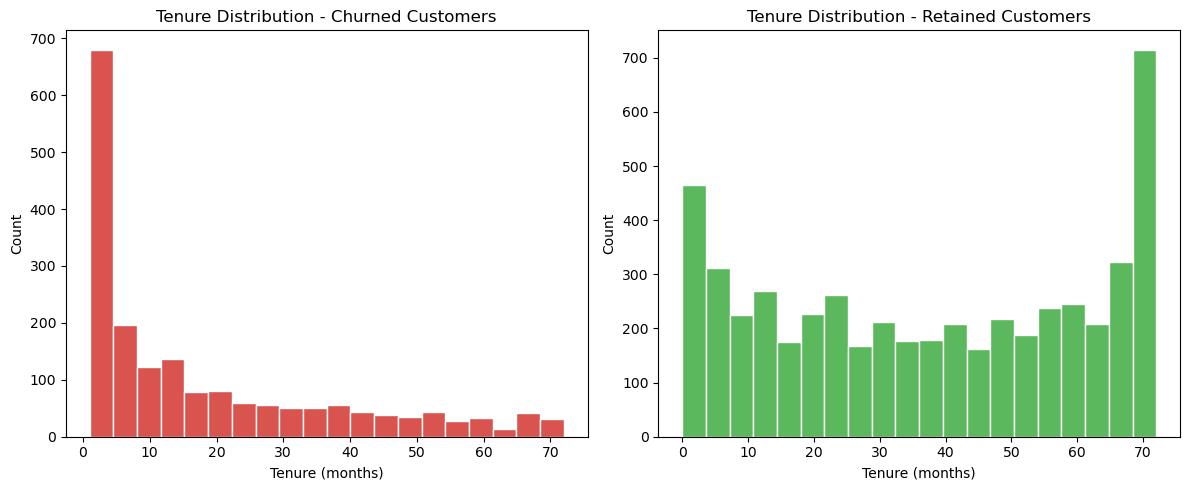

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churned customers
axes[0].hist(df[df["Churn"] == "Yes"]["tenure"], bins=20, color="#d9534f", edgecolor="white")
axes[0].set_title("Tenure Distribution - Churned Customers")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Count")

# Retained customers
axes[1].hist(df[df["Churn"] == "No"]["tenure"], bins=20, color="#5cb85c", edgecolor="white")
axes[1].set_title("Tenure Distribution - Retained Customers")
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

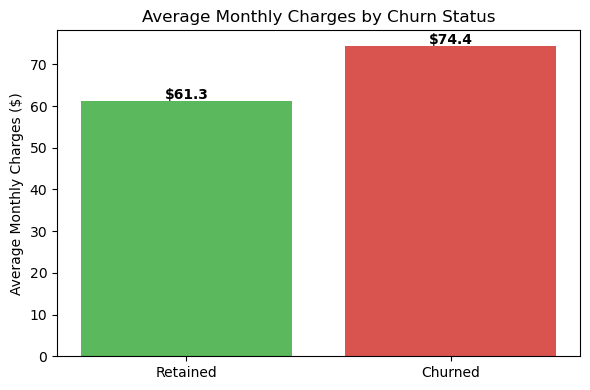

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

# Average monthly charges by churn status
avg_charges = df.groupby("Churn")["MonthlyCharges"].mean()
ax.bar(["Retained", "Churned"], 
       [avg_charges["No"], avg_charges["Yes"]], 
       color=["#5cb85c", "#d9534f"])

ax.set_title("Average Monthly Charges by Churn Status")
ax.set_ylabel("Average Monthly Charges ($)")

for i, v in enumerate([avg_charges["No"], avg_charges["Yes"]]):
    ax.text(i, v + 0.5, f"${v:.1f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

Churned customers are heavily concentrated in the first 10 months, while retained customers are more evenly distributed with a spike at 70+ months, suggesting that early-tenure customers are at highest churn risk.

### Contract Type and Churn

The visualization confirms the earlier SQL results.

Customers with month-to-month contracts have much higher churn compared to those with longer contracts.

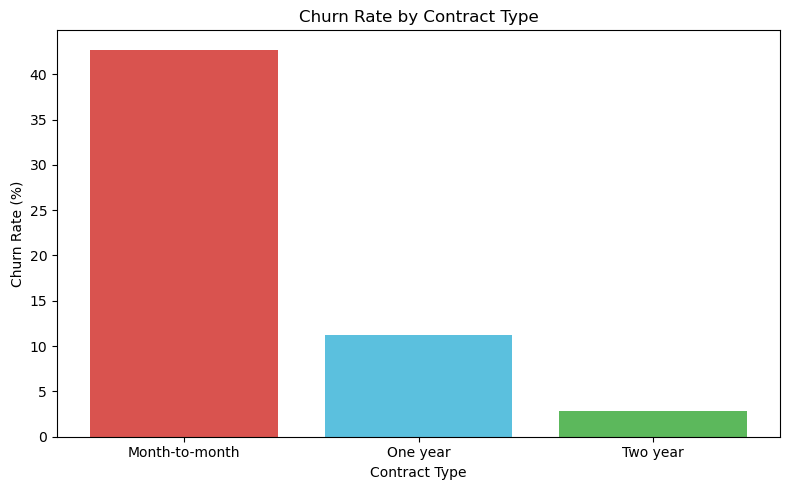

In [13]:
import matplotlib.pyplot as plt

contract_churn = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
).reset_index()
contract_churn.columns = ["Contract", "Churn Rate (%)"]

plt.figure(figsize=(8, 5))
plt.bar(contract_churn["Contract"], contract_churn["Churn Rate (%)"], color=["#d9534f", "#5bc0de", "#5cb85c"])
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.tight_layout()
plt.show()

## Logistic Regression Model

After exploring the data, I built a simple logistic regression model to predict churn.

I chose logistic regression because it is simple and easy to interpret, which is important for understanding the key drivers of churn.

In [14]:
df_model = df.copy()

In [15]:
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})

In [16]:
features = ["tenure", "MonthlyCharges", "Contract"]

In [17]:
df_model = pd.get_dummies(df_model, columns=["Contract"], drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [19]:
X = df_model[["tenure", "MonthlyCharges", "Contract_One year", "Contract_Two year"]]
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8026969481902059
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.53      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



### Model Performance

The model achieved about 80% accuracy.

However, since the dataset is slightly imbalanced, accuracy alone is not enough.  
The model provides a reasonable baseline for identifying churn risk.

This model is mainly used for interpretation rather than maximizing prediction accuracy.

In [22]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
1,MonthlyCharges,0.027562
0,tenure,-0.034583
2,Contract_One year,-1.017283
3,Contract_Two year,-1.999121


### Model Interpretation

From the logistic regression results:

- Customers with higher monthly charges are more likely to churn.
- Customers with longer tenure are less likely to churn.
- Customers with one-year or two-year contracts have significantly lower churn risk compared to month-to-month customers.

These results are consistent with the earlier SQL and visualization findings.

## Final Conclusion

In this project, I analyzed a telecom customer churn dataset using SQL, Python, and logistic regression.

From the analysis, the overall churn rate is about 26%.

Customers on month-to-month contracts have the highest churn rate, while customers with longer contracts are more likely to stay.

Customers with shorter tenure are more likely to churn, suggesting that newer customers are at higher risk.

Customers who churn tend to have higher monthly charges.

The logistic regression model confirms these findings, showing that contract type, tenure, and monthly charges are the key drivers of churn.

---

## Business Recommendations

Based on these findings, there are a few possible actions:

- Focus on retaining customers with month-to-month contracts, since they have the highest churn risk.
- Provide incentives for customers to switch to longer-term contracts.
- Pay more attention to new customers during the early stages of their subscription.
- Review pricing strategies for high-charge customers.





In [23]:
month_to_month = df[df["Contract"] == "Month-to-month"]

avg_monthly_charge = month_to_month["MonthlyCharges"].mean()
current_churned = month_to_month[month_to_month["Churn"] == "Yes"].shape[0]

retained_customers = current_churned * 0.05
estimated_annual_revenue = retained_customers * avg_monthly_charge * 12

estimated_annual_revenue

np.float64(65933.7008903226)

## Business Impact Estimate

Even a small reduction in churn can have a meaningful impact.

For example, if churn among month-to-month customers is reduced by 5%,  
the company could retain around $66,000 in annual revenue.

Overall, this project shows how data analysis and simple models can be used to support business decision-making.